In [106]:
# Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Load Data
df_songs = pd.read_csv("C:/fiifi/Shatta_Analytics_Project/Python_files/python_data_analysis/songs_fact.csv", index_col=0)
df_metrics = pd.read_csv("C:/fiifi/Shatta_Analytics_Project/Python_files/python_data_analysis/platform_metrics_dim.csv", index_col=0)

In [107]:
# Filter for youtube only
df_youtube = df_metrics[df_metrics["platform_name"] == "YouTube"].copy()

# Merge df_youtube & df_songs
df_merged = df_songs.merge(right=df_youtube, how="inner", on="song_id")

# Drop release_date_original and release_date_original.1
df_merged = df_merged.drop(columns=["release_date_original", "release_date_original.1"])

# Convert release_date  to datetime
df_merged["release_date"] = pd.to_datetime(df_merged["release_date"], dayfirst=False, errors="coerce")

In [108]:
# Get release_day
df_merged["day_no"] = pd.to_datetime(df_merged["release_date"]).dt.dayofweek
# df_merged["release_day_no"] = pd.to_datetime(df_merged["release_date"]).dt.day

# # Get full day name
df_merged["day_name"] = pd.to_datetime(df_merged["release_date"]).dt.day_name()
# df_merged["release_day"] = df_merged["release_date"].dt.strftime("%a")

# Calculate song age
reference_date = datetime.now()
df_merged["age_days"] = (reference_date - df_merged["release_date"]).dt.days

# Only include songs that are >= 90 days
df_mature = df_merged[df_merged["age_days"] >= 90].copy()

# sort by day_no
df_mature = df_merged.sort_values(by="day_no", ascending=True).copy()

# Group by day_name
df_optimal_day = df_mature.groupby(by="day_name")["views"].agg(["mean", "median"]).round(1).sort_values(by="mean", ascending=False)

In [109]:
df_optimal_day

,mean,median
day_name,,
Wednesday,777398.5,77070.0
Sunday,563950.9,90615.5
Thursday,370747.1,61115.0
Saturday,289103.8,79666.0
Tuesday,287389.3,69080.0
Friday,286573.6,95820.0
Monday,188201.3,54116.0


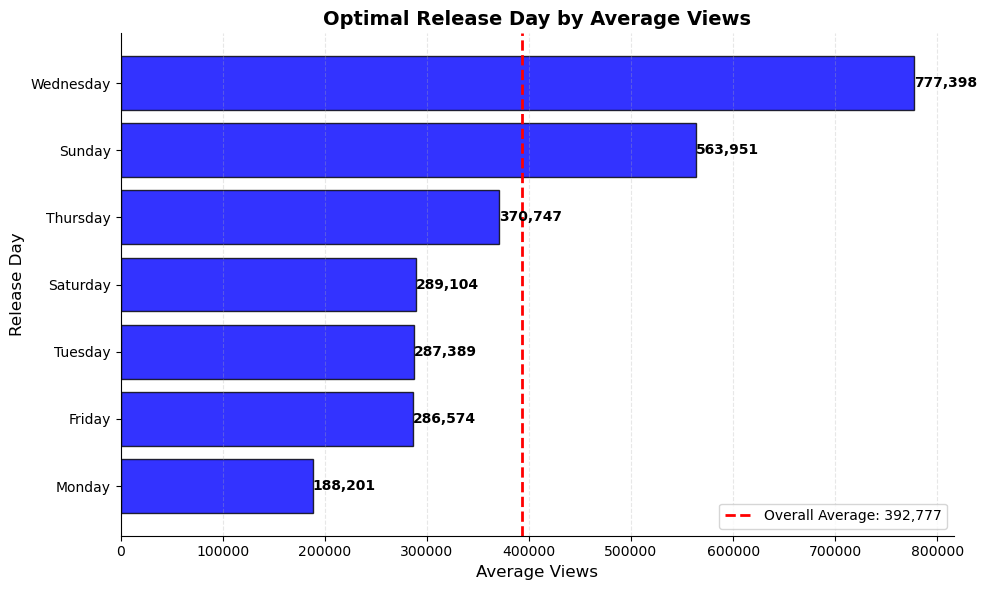

In [110]:
# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))

# Plot horizontal bars
bars = ax.barh(df_optimal_day.index, df_optimal_day['mean'], color='blue', edgecolor='black', alpha=0.8)

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars, df_optimal_day['mean'])):
    ax.text(value, bar.get_y() + bar.get_height()/2, f'{value:,.0f}', 
            va='center', ha='left', fontsize=10, fontweight='bold')

# Customize the chart
ax.set_xlabel('Average Views', fontsize=12)
ax.set_ylabel('Release Day', fontsize=12)
ax.set_title('Optimal Release Day by Average Views', fontsize=14, fontweight='bold')
ax.invert_yaxis()  # Best day at top
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Despine - remove right and top spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Add a vertical line for overall average
overall_avg = df_merged['views'].mean()
ax.axvline(x=overall_avg, color='red', linestyle='--', linewidth=2, 
           label=f'Overall Average: {overall_avg:,.0f}')

# Add legend
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

Insights:
- Wednesday is the strongest release day by far – With 777,398 average views, Wednesday outperforms the second-best day (Sunday at 563,951) by over 200,000 views
- Sunday and Thursday are the second-tier release windows – Both generate over 350,000 average views, making them solid alternatives to Wednesday
- Monday is the weakest release day – At only 188,201 average views, Monday releases underperform by nearly 4x compared to Wednesday

Recommendations
- Schedule major singles and album releases on Wednesdays – This gives songs a full week of momentum heading into the weekend
- Avoid Monday releases entirely – The data clearly shows Monday is the worst-performing day; save Monday for announcements, not music drops
- Use Sunday or Thursday for secondary releases – If Wednesday is unavailable, these are your next best options based on historical performance